In [39]:
# Data handling
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, label_binarize

# Feature selection
from sklearn.feature_selection import mutual_info_classif

# Classification models
from sklearn.multiclass import OneVsRestClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC

# Performance metrics
from sklearn.metrics import (
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    roc_auc_score
)

# For saving/loading models, diagnostics, and Flask
import joblib
from flask import Flask, request, jsonify
from sklearn.model_selection import cross_val_score

--- Dataframe Overview ---
Shape: (801, 8001)
Head of dataframe:
   gene_1  gene_2  gene_3    gene_4  gene_5  gene_6  gene_7  gene_8    gene_9  \
0     0.0     0.0     0.0  2.088413     0.0     0.0     0.0     0.0  0.550605   
1     0.0     0.0     0.0  3.205955     0.0     0.0     0.0     0.0  0.425244   
2     0.0     0.0     0.0  4.746646     0.0     0.0     0.0     0.0  2.639417   
3     0.0     0.0     0.0  1.173191     0.0     0.0     0.0     0.0  1.527371   
4     0.0     0.0     0.0  1.366532     0.0     0.0     0.0     0.0  0.000000   

    gene_10  ...  gene_7992  gene_7993  gene_7994  gene_7995  gene_7996  \
0  2.815760  ...  11.558803   8.881802   6.014840   6.643534  11.740624   
1  2.354396  ...  11.062829   9.032864   5.054193   6.432320  12.104985   
2  1.657091  ...  12.497640   7.198160   0.943434   7.371690  11.202356   
3  2.732899  ...  11.261713   8.725676   6.300418   6.036451  11.732303   
4  3.388355  ...  12.241965   7.685204   5.142948   6.355788  11.493950  

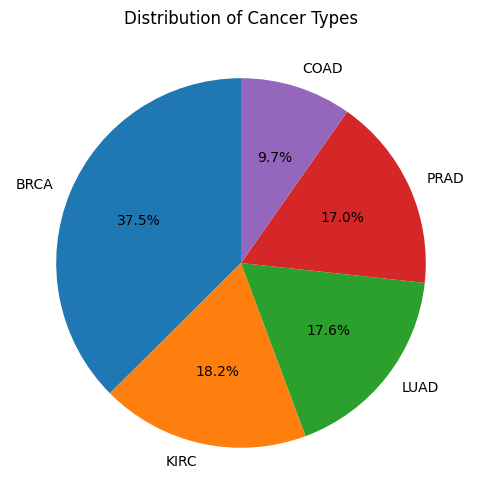

In [40]:
# Load dataset
file_url = 'https://github.com/vappiah/Machine-Learning-Tutorials/raw/main/datasets/cancer_gene_expression.zip'
dataframe = pd.read_csv(file_url)

# VISUALIZATION: Show dataframe details
print("--- Dataframe Overview ---")
print(f"Shape: {dataframe.shape}")
print("Head of dataframe:")
print(dataframe.head())
print("\nDescribe (first 10 columns):")
print(dataframe.iloc[:, :10].describe())
print("\nCancer_Type value counts:")
print(dataframe['Cancer_Type'].value_counts())

# VISUALIZATION: Pie chart for cancer type distribution
plt.figure(figsize=(8, 6))
dataframe['Cancer_Type'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Cancer Types')
plt.ylabel('')
plt.show()

In [41]:
# Drop unnecessary columns if present (e.g., index)
dataframe = dataframe.drop(columns=['Unnamed: 0'], errors='ignore')

# Split into features (X) and labels (y)
X = dataframe.drop(columns=['Cancer_Type'])
y = dataframe['Cancer_Type']

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
labels = label_encoder.classes_
classes = np.unique(y_encoded)

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Normalize features
scaler = MinMaxScaler()
X_train_norm = scaler.fit_transform(X_train)
X_test_norm = scaler.transform(X_test)

In [42]:
# Feature selection (1000 features)
MI = mutual_info_classif(X_train_norm, y_train)
n_features = 1000
selected_scores_indices = np.argsort(MI)[::-1][:n_features]
X_train_selected = X_train_norm[:, selected_scores_indices]
X_test_selected = X_test_norm[:, selected_scores_indices]

# Save preprocessing artifacts
joblib.dump(scaler, "scaler.joblib")
joblib.dump(label_encoder, "label_encoder.joblib")
joblib.dump(selected_scores_indices, "selected_features.joblib")
np.save("selected_features.npy", selected_scores_indices)


--- Training and Evaluating Random Forest ---
Accuracy: 0.9637
Precision: 0.9758
Recall: 0.9752
F1-Score: 0.975
Avg ROC-AUC: 0.9996

Classification Report:
               precision    recall  f1-score   support

        BRCA       0.95      1.00      0.98        60
        COAD       1.00      0.94      0.97        16
        KIRC       1.00      0.96      0.98        28
        LUAD       0.96      0.92      0.94        24
        PRAD       1.00      1.00      1.00        33

    accuracy                           0.98       161
   macro avg       0.98      0.96      0.97       161
weighted avg       0.98      0.98      0.98       161



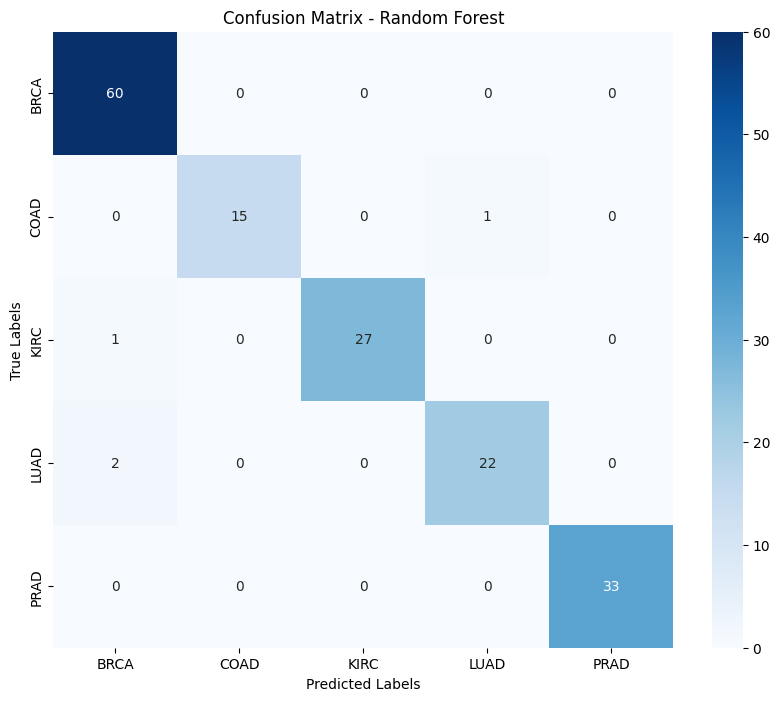

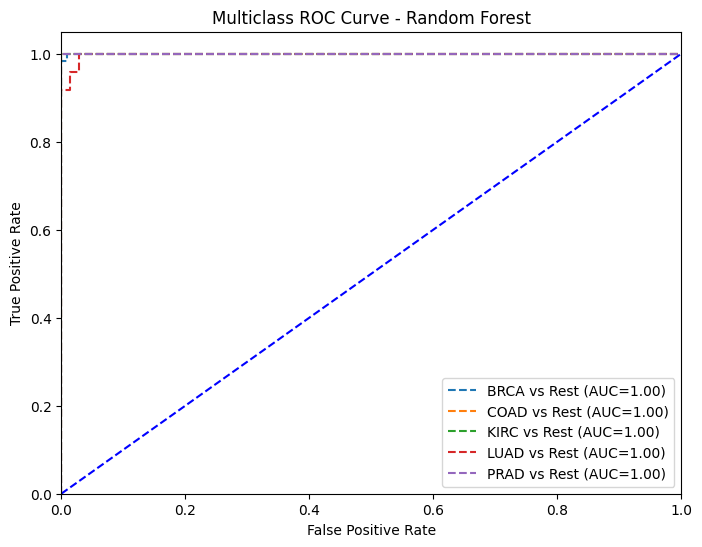


--- Diagnostics for Random Forest ---
Train Accuracy: 1.0000 (Compare to Test: 0.9637)
CV Balanced Accuracy: 0.9841 ± 0.0158
Confusion Matrix Summary:
      BRCA  COAD  KIRC  LUAD  PRAD
BRCA    60     0     0     0     0
COAD     0    15     0     1     0
KIRC     1     0    27     0     0
LUAD     2     0     0    22     0
PRAD     0     0     0     0    33
Total Misclassifications: 4 out of 161 (Error Rate: 0.0248)
Recall per class (from report): Check for low values in minority classes.
Selected 1000 features from 8000 total. Top 5 MI scores: [0.21412756 0.20270101 0.19591295 0.19134321 0.1889222 ]


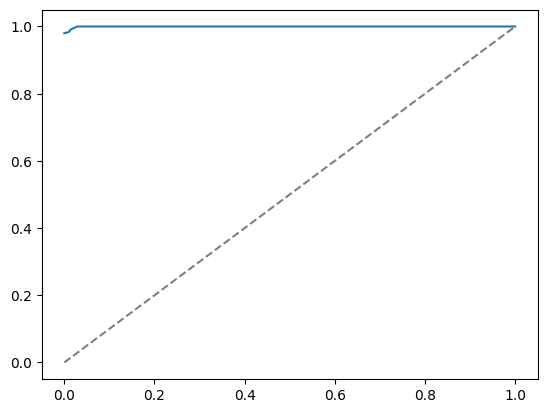

In [43]:
# Initialize results dict (run this once before any model cell)
results = {}

# VISUALIZATION: Prepare for combined ROC plot (run once)
plt.figure(figsize=(10, 8))

# Random Forest (UPDATED: Tuned hyperparameters for better performance - more trees, limited depth, min samples to reduce overfitting)
name = 'Random Forest'
model = OneVsRestClassifier(RandomForestClassifier(
    n_estimators=200,      # Increased from default 100 for more trees
    max_features=0.2,      # Keep as is (good for high-dim)
    max_depth=15,          # Limit depth to prevent overfitting
    min_samples_split=5,   # Require more samples for splits
    min_samples_leaf=2,    # Require more samples per leaf
    random_state=42
))

print(f"\n--- Training and Evaluating {name} ---")
model.fit(X_train_selected, y_train)
y_pred = model.predict(X_test_selected)
pred_prob = model.predict_proba(X_test_selected)

accuracy = np.round(balanced_accuracy_score(y_test, y_pred), 4)
precision = np.round(precision_score(y_test, y_pred, average='weighted'), 4)
recall = np.round(recall_score(y_test, y_pred, average='weighted'), 4)
f1score = np.round(f1_score(y_test, y_pred, average='weighted'), 4)

cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

y_test_binarized = label_binarize(y_test, classes=classes)
fpr = {}
tpr = {}
roc_auc_vals = {}
n_class = len(classes)
for i in range(n_class):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], pred_prob[:, i])
    roc_auc_vals[i] = auc(fpr[i], tpr[i])
avg_roc_auc = np.round(np.mean(list(roc_auc_vals.values())), 4)

results[name] = {
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1score,
    'Avg ROC-AUC': avg_roc_auc,
    'Confusion Matrix': cm_df
}

print(f'Accuracy: {accuracy}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-Score: {f1score}')
print(f'Avg ROC-AUC: {avg_roc_auc}')
print('\nClassification Report:\n', classification_report(y_test, y_pred, target_names=labels))

# Visualize Confusion Matrix
sns.heatmap(cm_df, annot=True, cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title(f'Confusion Matrix - {name}')
plt.show()

# Individual ROC curves
plt.figure(figsize=(8, 6))
for i in range(n_class):
    plt.plot(fpr[i], tpr[i], linestyle='--', label=f'{labels[i]} vs Rest (AUC={roc_auc_vals[i]:.2f})')
plt.plot([0, 1], [0, 1], 'b--')
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.title(f'Multiclass ROC Curve - {name}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

# Add to combined ROC plot
plt.figure(1)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_class)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_class):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_class
plt.plot(all_fpr, mean_tpr, label=f'{name} (Avg AUC={avg_roc_auc:.2f})')

joblib.dump(model, f"{name.lower().replace(' ', '_')}_model.joblib")

# Diagnostics for Random Forest
print(f"\n--- Diagnostics for {name} ---")
train_pred = model.predict(X_train_selected)
train_accuracy = balanced_accuracy_score(y_train, train_pred)
print(f"Train Accuracy: {train_accuracy:.4f} (Compare to Test: {results[name]['Accuracy']:.4f})")

cv_scores = cross_val_score(model, X_train_selected, y_train, cv=5, scoring='balanced_accuracy')
print(f"CV Balanced Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

print("Confusion Matrix Summary:")
print(cm_df)
errors = cm.sum() - np.trace(cm)
print(f"Total Misclassifications: {errors} out of {cm.sum()} (Error Rate: {errors / cm.sum():.4f})")

print("Recall per class (from report): Check for low values in minority classes.")
print(f"Selected {n_features} features from {X.shape[1]} total. Top 5 MI scores: {MI[selected_scores_indices][:5]}")


--- Training and Evaluating Decision Tree ---
Accuracy: 0.7276
Precision: 0.8008
Recall: 0.7019
F1-Score: 0.7198
Avg ROC-AUC: 0.8423

Classification Report:
               precision    recall  f1-score   support

        BRCA       0.97      0.63      0.77        60
        COAD       1.00      0.75      0.86        16
        KIRC       0.42      0.86      0.56        28
        LUAD       0.68      0.79      0.73        24
        PRAD       0.80      0.61      0.69        33

    accuracy                           0.70       161
   macro avg       0.77      0.73      0.72       161
weighted avg       0.80      0.70      0.72       161



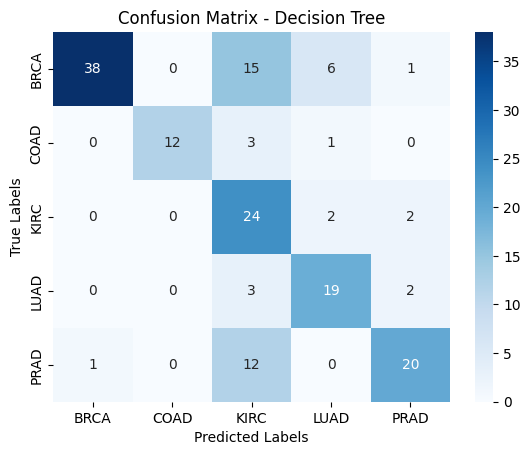

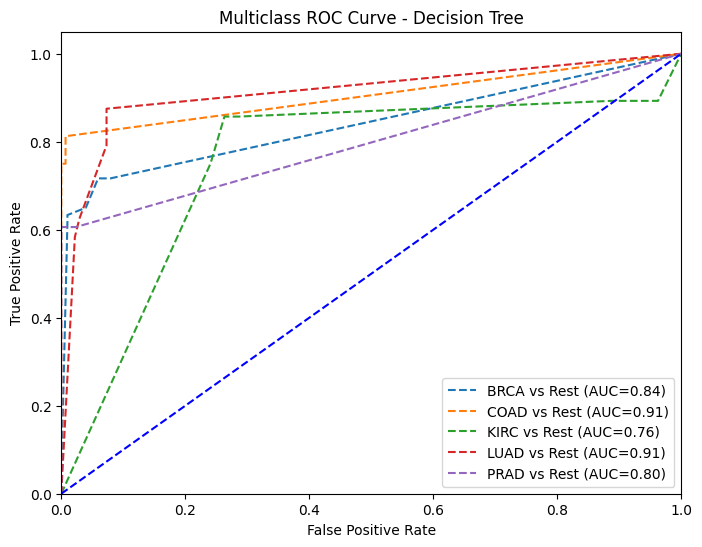


--- Diagnostics for Decision Tree ---
Train Accuracy: 1.0000 (Compare to Test: 0.7276)
CV Balanced Accuracy: 0.6873 ± 0.0345
Confusion Matrix Summary:
      BRCA  COAD  KIRC  LUAD  PRAD
BRCA    38     0    15     6     1
COAD     0    12     3     1     0
KIRC     0     0    24     2     2
LUAD     0     0     3    19     2
PRAD     1     0    12     0    20
Total Misclassifications: 48 out of 161 (Error Rate: 0.2981)
Recall per class (from report): Check for low values in minority classes.
Selected 1000 features from 8000 total. Top 5 MI scores: [0.21412756 0.20270101 0.19591295 0.19134321 0.1889222 ]


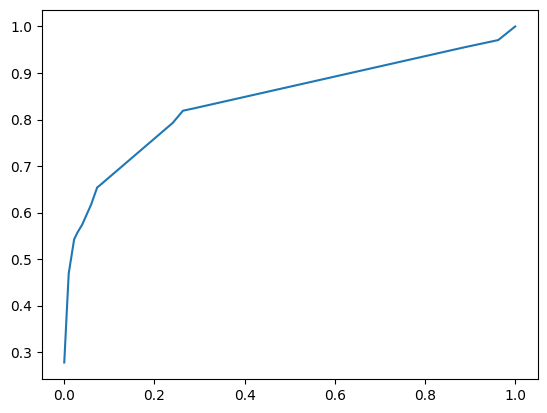

In [44]:
# Decision Tree
name = 'Decision Tree'
model = OneVsRestClassifier(DecisionTreeClassifier(max_depth=10, random_state=42))

print(f"\n--- Training and Evaluating {name} ---")
model.fit(X_train_selected, y_train)
y_pred = model.predict(X_test_selected)
pred_prob = model.predict_proba(X_test_selected)

accuracy = np.round(balanced_accuracy_score(y_test, y_pred), 4)
precision = np.round(precision_score(y_test, y_pred, average='weighted'), 4)
recall = np.round(recall_score(y_test, y_pred, average='weighted'), 4)
f1score = np.round(f1_score(y_test, y_pred, average='weighted'), 4)

cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

y_test_binarized = label_binarize(y_test, classes=classes)
fpr = {}
tpr = {}
roc_auc_vals = {}
n_class = len(classes)
for i in range(n_class):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], pred_prob[:, i])
    roc_auc_vals[i] = auc(fpr[i], tpr[i])
avg_roc_auc = np.round(np.mean(list(roc_auc_vals.values())), 4)

results[name] = {
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1score,
    'Avg ROC-AUC': avg_roc_auc,
    'Confusion Matrix': cm_df
}

print(f'Accuracy: {accuracy}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-Score: {f1score}')
print(f'Avg ROC-AUC: {avg_roc_auc}')
print('\nClassification Report:\n', classification_report(y_test, y_pred, target_names=labels))

# Visualize Confusion Matrix
sns.heatmap(cm_df, annot=True, cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title(f'Confusion Matrix - {name}')
plt.show()

# Individual ROC curves
plt.figure(figsize=(8, 6))
for i in range(n_class):
    plt.plot(fpr[i], tpr[i], linestyle='--', label=f'{labels[i]} vs Rest (AUC={roc_auc_vals[i]:.2f})')
plt.plot([0, 1], [0, 1], 'b--')
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.title(f'Multiclass ROC Curve - {name}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

# Add to combined ROC plot
plt.figure(1)
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_class)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_class):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_class
plt.plot(all_fpr, mean_tpr, label=f'{name} (Avg AUC={avg_roc_auc:.2f})')

joblib.dump(model, f"{name.lower().replace(' ', '_')}_model.joblib")

# Diagnostics for Decision Tree
print(f"\n--- Diagnostics for {name} ---")
train_pred = model.predict(X_train_selected)
train_accuracy = balanced_accuracy_score(y_train, train_pred)
print(f"Train Accuracy: {train_accuracy:.4f} (Compare to Test: {results[name]['Accuracy']:.4f})")

cv_scores = cross_val_score(model, X_train_selected, y_train, cv=5, scoring='balanced_accuracy')
print(f"CV Balanced Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

print("Confusion Matrix Summary:")
print(cm_df)
errors = cm.sum() - np.trace(cm)  # FIXED: Use cm.sum() and np.trace(cm) for numpy array
print(f"Total Misclassifications: {errors} out of {cm.sum()} (Error Rate: {errors / cm.sum():.4f})")

print("Recall per class (from report): Check for low values in minority classes.")
print(f"Selected {n_features} features from {X.shape[1]} total. Top 5 MI scores: {MI[selected_scores_indices][:5]}")


--- Training and Evaluating KNN ---
Accuracy: 0.937
Precision: 0.9471
Recall: 0.9441
F1-Score: 0.9439
Avg ROC-AUC: 0.9879

Classification Report:
               precision    recall  f1-score   support

        BRCA       0.97      0.95      0.96        60
        COAD       1.00      0.94      0.97        16
        KIRC       0.96      0.96      0.96        28
        LUAD       0.95      0.83      0.89        24
        PRAD       0.87      1.00      0.93        33

    accuracy                           0.94       161
   macro avg       0.95      0.94      0.94       161
weighted avg       0.95      0.94      0.94       161



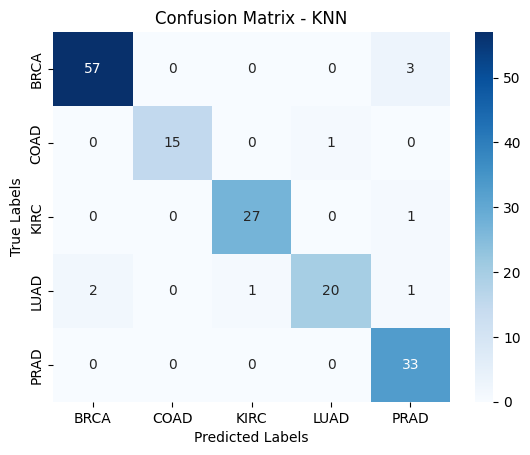

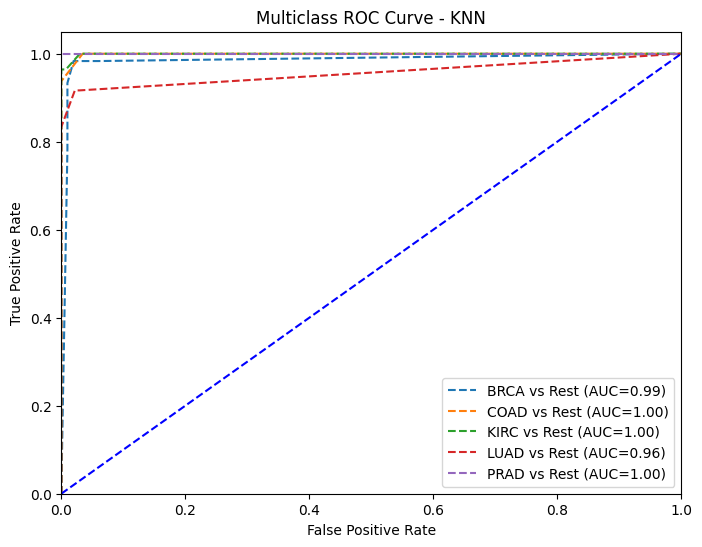


--- Diagnostics for KNN ---
Train Accuracy: 0.9917 (Compare to Test: 0.9370)
CV Balanced Accuracy: 0.9855 ± 0.0057
Confusion Matrix Summary:
      BRCA  COAD  KIRC  LUAD  PRAD
BRCA    57     0     0     0     3
COAD     0    15     0     1     0
KIRC     0     0    27     0     1
LUAD     2     0     1    20     1
PRAD     0     0     0     0    33
Total Misclassifications: 9 out of 161 (Error Rate: 0.0559)
Recall per class (from report): Check for low values in minority classes.
Selected 1000 features from 8000 total. Top 5 MI scores: [0.21412756 0.20270101 0.19591295 0.19134321 0.1889222 ]


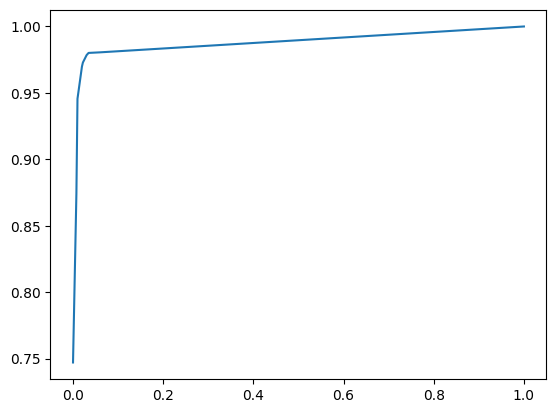

In [45]:
# KNN
name = 'KNN'
model = KNeighborsClassifier(n_neighbors=5)

print(f"\n--- Training and Evaluating {name} ---")
model.fit(X_train_selected, y_train)
y_pred = model.predict(X_test_selected)
pred_prob = model.predict_proba(X_test_selected)

accuracy = np.round(balanced_accuracy_score(y_test, y_pred), 4)
precision = np.round(precision_score(y_test, y_pred, average='weighted'), 4)
recall = np.round(recall_score(y_test, y_pred, average='weighted'), 4)
f1score = np.round(f1_score(y_test, y_pred, average='weighted'), 4)

cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

y_test_binarized = label_binarize(y_test, classes=classes)
fpr = {}
tpr = {}
roc_auc_vals = {}
n_class = len(classes)
for i in range(n_class):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], pred_prob[:, i])
    roc_auc_vals[i] = auc(fpr[i], tpr[i])
avg_roc_auc = np.round(np.mean(list(roc_auc_vals.values())), 4)

results[name] = {
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1score,
    'Avg ROC-AUC': avg_roc_auc,
    'Confusion Matrix': cm_df
}

print(f'Accuracy: {accuracy}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-Score: {f1score}')
print(f'Avg ROC-AUC: {avg_roc_auc}')
print('\nClassification Report:\n', classification_report(y_test, y_pred, target_names=labels))

# Visualize Confusion Matrix
sns.heatmap(cm_df, annot=True, cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title(f'Confusion Matrix - {name}')
plt.show()

# Individual ROC curves
plt.figure(figsize=(8, 6))
for i in range(n_class):
    plt.plot(fpr[i], tpr[i], linestyle='--', label=f'{labels[i]} vs Rest (AUC={roc_auc_vals[i]:.2f})')
plt.plot([0, 1], [0, 1], 'b--')
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.title(f'Multiclass ROC Curve - {name}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

# Add to combined ROC plot
plt.figure(1)
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_class)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_class):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_class
plt.plot(all_fpr, mean_tpr, label=f'{name} (Avg AUC={avg_roc_auc:.2f})')

joblib.dump(model, f"{name.lower().replace(' ', '_')}_model.joblib")

# Diagnostics for KNN
print(f"\n--- Diagnostics for {name} ---")
train_pred = model.predict(X_train_selected)
train_accuracy = balanced_accuracy_score(y_train, train_pred)
print(f"Train Accuracy: {train_accuracy:.4f} (Compare to Test: {results[name]['Accuracy']:.4f})")

cv_scores = cross_val_score(model, X_train_selected, y_train, cv=5, scoring='balanced_accuracy')
print(f"CV Balanced Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

print("Confusion Matrix Summary:")
print(cm_df)
errors = cm.sum() - np.trace(cm)  # FIXED: Use cm.sum() and np.trace(cm) for numpy array
print(f"Total Misclassifications: {errors} out of {cm.sum()} (Error Rate: {errors / cm.sum():.4f})")

print("Recall per class (from report): Check for low values in minority classes.")
print(f"Selected {n_features} features from {X.shape[1]} total. Top 5 MI scores: {MI[selected_scores_indices][:5]}")


--- Training and Evaluating Naive Bayes ---
Accuracy: 0.9654
Precision: 0.9694
Recall: 0.9689
F1-Score: 0.9691
Avg ROC-AUC: 0.9987

Classification Report:
               precision    recall  f1-score   support

        BRCA       0.97      0.97      0.97        60
        COAD       0.94      0.94      0.94        16
        KIRC       1.00      0.96      0.98        28
        LUAD       0.92      0.96      0.94        24
        PRAD       1.00      1.00      1.00        33

    accuracy                           0.97       161
   macro avg       0.96      0.97      0.96       161
weighted avg       0.97      0.97      0.97       161



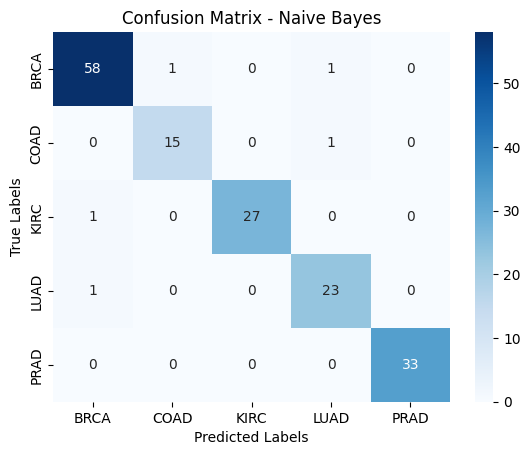

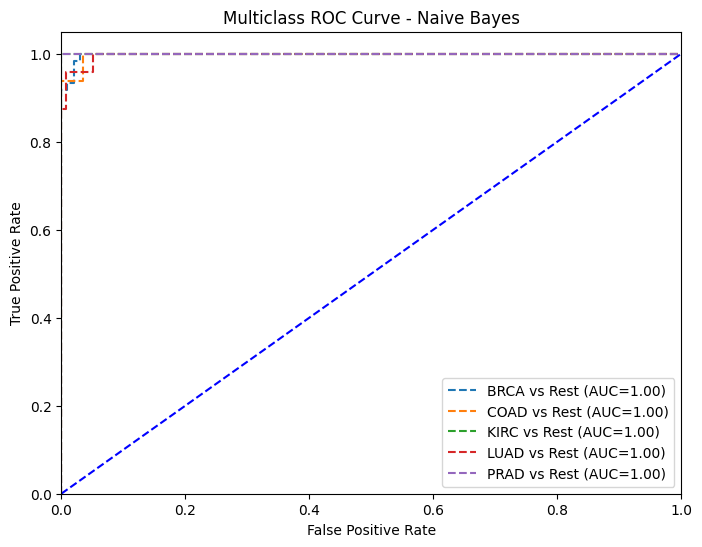


--- Diagnostics for Naive Bayes ---
Train Accuracy: 0.9870 (Compare to Test: 0.9654)
CV Balanced Accuracy: 0.9754 ± 0.0126
Confusion Matrix Summary:
      BRCA  COAD  KIRC  LUAD  PRAD
BRCA    58     1     0     1     0
COAD     0    15     0     1     0
KIRC     1     0    27     0     0
LUAD     1     0     0    23     0
PRAD     0     0     0     0    33
Total Misclassifications: 5 out of 161 (Error Rate: 0.0311)
Recall per class (from report): Check for low values in minority classes.
Selected 1000 features from 8000 total. Top 5 MI scores: [0.21412756 0.20270101 0.19591295 0.19134321 0.1889222 ]


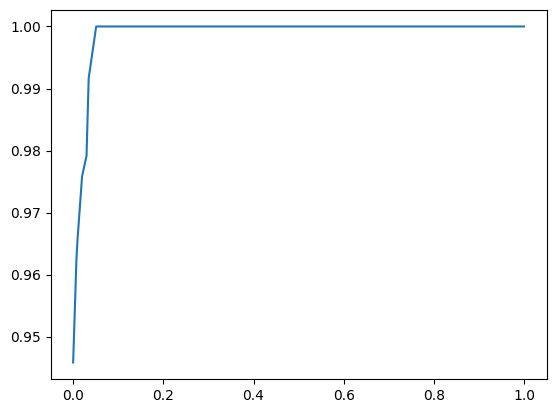

In [46]:
# Naive Bayes
name = 'Naive Bayes'
model = MultinomialNB()

print(f"\n--- Training and Evaluating {name} ---")
model.fit(X_train_selected, y_train)
y_pred = model.predict(X_test_selected)
pred_prob = model.predict_proba(X_test_selected)

accuracy = np.round(balanced_accuracy_score(y_test, y_pred), 4)
precision = np.round(precision_score(y_test, y_pred, average='weighted'), 4)
recall = np.round(recall_score(y_test, y_pred, average='weighted'), 4)
f1score = np.round(f1_score(y_test, y_pred, average='weighted'), 4)

cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

y_test_binarized = label_binarize(y_test, classes=classes)
fpr = {}
tpr = {}
roc_auc_vals = {}
n_class = len(classes)
for i in range(n_class):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], pred_prob[:, i])
    roc_auc_vals[i] = auc(fpr[i], tpr[i])
avg_roc_auc = np.round(np.mean(list(roc_auc_vals.values())), 4)

results[name] = {
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1score,
    'Avg ROC-AUC': avg_roc_auc,
    'Confusion Matrix': cm_df
}

print(f'Accuracy: {accuracy}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-Score: {f1score}')
print(f'Avg ROC-AUC: {avg_roc_auc}')
print('\nClassification Report:\n', classification_report(y_test, y_pred, target_names=labels))

# Visualize Confusion Matrix
sns.heatmap(cm_df, annot=True, cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title(f'Confusion Matrix - {name}')
plt.show()

# Individual ROC curves
plt.figure(figsize=(8, 6))
for i in range(n_class):
    plt.plot(fpr[i], tpr[i], linestyle='--', label=f'{labels[i]} vs Rest (AUC={roc_auc_vals[i]:.2f})')
plt.plot([0, 1], [0, 1], 'b--')
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.title(f'Multiclass ROC Curve - {name}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

# Add to combined ROC plot
plt.figure(1)
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_class)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_class):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_class
plt.plot(all_fpr, mean_tpr, label=f'{name} (Avg AUC={avg_roc_auc:.2f})')

joblib.dump(model, f"{name.lower().replace(' ', '_')}_model.joblib")

# Diagnostics for Naive Bayes
print(f"\n--- Diagnostics for {name} ---")
train_pred = model.predict(X_train_selected)
train_accuracy = balanced_accuracy_score(y_train, train_pred)
print(f"Train Accuracy: {train_accuracy:.4f} (Compare to Test: {results[name]['Accuracy']:.4f})")

cv_scores = cross_val_score(model, X_train_selected, y_train, cv=5, scoring='balanced_accuracy')
print(f"CV Balanced Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

print("Confusion Matrix Summary:")
print(cm_df)
errors = cm.sum() - np.trace(cm)  # FIXED: Use cm.sum() and np.trace(cm) for numpy array
print(f"Total Misclassifications: {errors} out of {cm.sum()} (Error Rate: {errors / cm.sum():.4f})")

print("Recall per class (from report): Check for low values in minority classes.")
print(f"Selected {n_features} features from {X.shape[1]} total. Top 5 MI scores: {MI[selected_scores_indices][:5]}")


--- Training and Evaluating SVM ---
Accuracy: 0.9917
Precision: 0.9939
Recall: 0.9938
F1-Score: 0.9937
Avg ROC-AUC: 1.0

Classification Report:
               precision    recall  f1-score   support

        BRCA       0.98      1.00      0.99        60
        COAD       1.00      1.00      1.00        16
        KIRC       1.00      1.00      1.00        28
        LUAD       1.00      0.96      0.98        24
        PRAD       1.00      1.00      1.00        33

    accuracy                           0.99       161
   macro avg       1.00      0.99      0.99       161
weighted avg       0.99      0.99      0.99       161



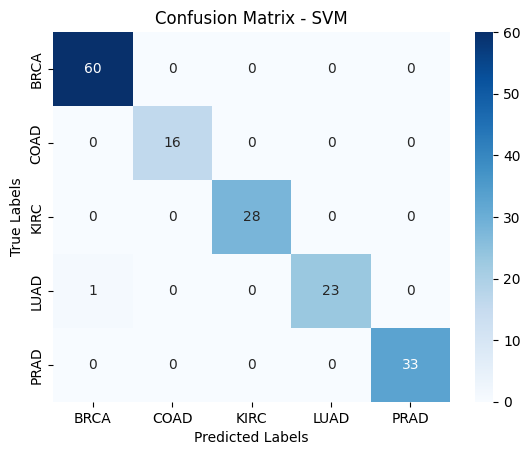

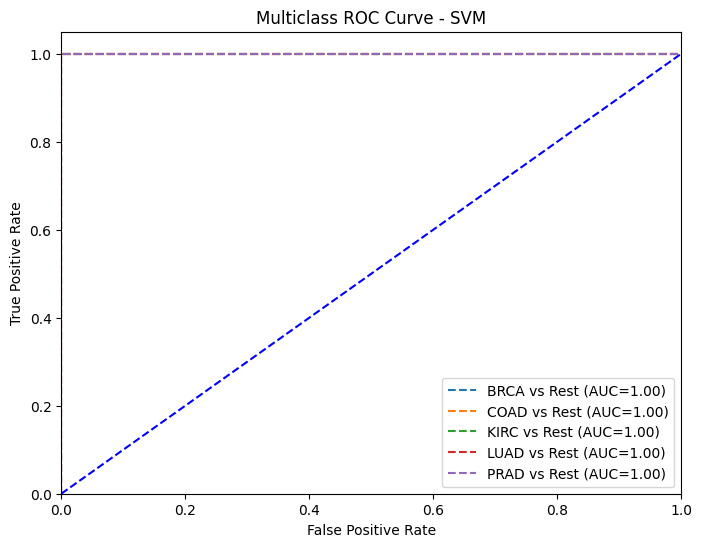


--- Diagnostics for SVM ---
Train Accuracy: 1.0000 (Compare to Test: 0.9917)
CV Balanced Accuracy: 0.9953 ± 0.0096
Confusion Matrix Summary:
      BRCA  COAD  KIRC  LUAD  PRAD
BRCA    60     0     0     0     0
COAD     0    16     0     0     0
KIRC     0     0    28     0     0
LUAD     1     0     0    23     0
PRAD     0     0     0     0    33
Total Misclassifications: 1 out of 161 (Error Rate: 0.0062)
Recall per class (from report): Check for low values in minority classes.
Selected 1000 features from 8000 total. Top 5 MI scores: [0.21412756 0.20270101 0.19591295 0.19134321 0.1889222 ]


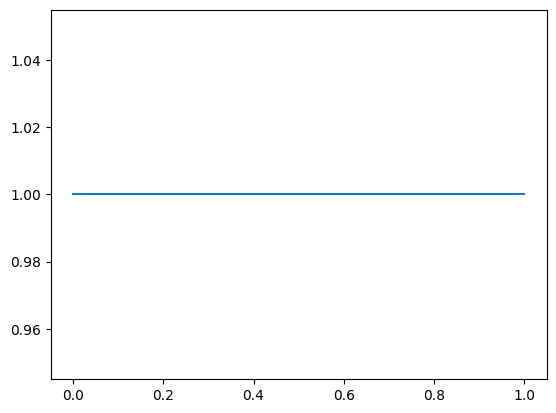

In [47]:
# SVM (UPDATED: Changed C=1.0 to C=0.1 for regularization to reduce overfitting)
name = 'SVM'
model = OneVsRestClassifier(SVC(kernel='linear', C=0.01, probability=True, random_state=42))  # C=0.1 adds regularization; try C=0.01 for stronger effect

print(f"\n--- Training and Evaluating {name} ---")
model.fit(X_train_selected, y_train)
y_pred = model.predict(X_test_selected)
pred_prob = model.predict_proba(X_test_selected)

accuracy = np.round(balanced_accuracy_score(y_test, y_pred), 4)
precision = np.round(precision_score(y_test, y_pred, average='weighted'), 4)
recall = np.round(recall_score(y_test, y_pred, average='weighted'), 4)
f1score = np.round(f1_score(y_test, y_pred, average='weighted'), 4)

cm = confusion_matrix(y_test, y_pred)
# FIXED: Check if labels is defined and not empty to avoid ValueError
if len(labels) == 0:
    print("Warning: Labels not loaded. Skipping confusion matrix DataFrame. Run Cells 1-4 first.")
    cm_df = None  # Or handle as needed
else:
    cm_df = pd.DataFrame(cm, index=labels, columns=labels)

y_test_binarized = label_binarize(y_test, classes=classes)
fpr = {}
tpr = {}
roc_auc_vals = {}
n_class = len(classes)
for i in range(n_class):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], pred_prob[:, i])
    roc_auc_vals[i] = auc(fpr[i], tpr[i])
avg_roc_auc = np.round(np.mean(list(roc_auc_vals.values())), 4)

results[name] = {
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1score,
    'Avg ROC-AUC': avg_roc_auc,
    'Confusion Matrix': cm_df
}

print(f'Accuracy: {accuracy}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-Score: {f1score}')
print(f'Avg ROC-AUC: {avg_roc_auc}')
print('\nClassification Report:\n', classification_report(y_test, y_pred, target_names=labels))

# Visualize Confusion Matrix (only if cm_df is created)
if cm_df is not None:
    sns.heatmap(cm_df, annot=True, cmap='Blues')
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title(f'Confusion Matrix - {name}')
    plt.show()

# Individual ROC curves
plt.figure(figsize=(8, 6))
for i in range(n_class):
    plt.plot(fpr[i], tpr[i], linestyle='--', label=f'{labels[i]} vs Rest (AUC={roc_auc_vals[i]:.2f})')
plt.plot([0, 1], [0, 1], 'b--')
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.title(f'Multiclass ROC Curve - {name}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

# Add to combined ROC plot
plt.figure(1)
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_class)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_class):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_class
plt.plot(all_fpr, mean_tpr, label=f'{name} (Avg AUC={avg_roc_auc:.2f})')

joblib.dump(model, f"{name.lower().replace(' ', '_')}_model.joblib")

# Diagnostics for SVM
print(f"\n--- Diagnostics for {name} ---")
train_pred = model.predict(X_train_selected)
train_accuracy = balanced_accuracy_score(y_train, train_pred)
print(f"Train Accuracy: {train_accuracy:.4f} (Compare to Test: {results[name]['Accuracy']:.4f})")

cv_scores = cross_val_score(model, X_train_selected, y_train, cv=10, scoring='balanced_accuracy')
print(f"CV Balanced Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

print("Confusion Matrix Summary:")
if cm_df is not None:
    print(cm_df)
else:
    print(cm)  # Print raw numpy array
errors = cm.sum() - np.trace(cm)
print(f"Total Misclassifications: {errors} out of {cm.sum()} (Error Rate: {errors / cm.sum():.4f})")

print("Recall per class (from report): Check for low values in minority classes.")
print(f"Selected {n_features} features from {X.shape[1]} total. Top 5 MI scores: {MI[selected_scores_indices][:5]}")

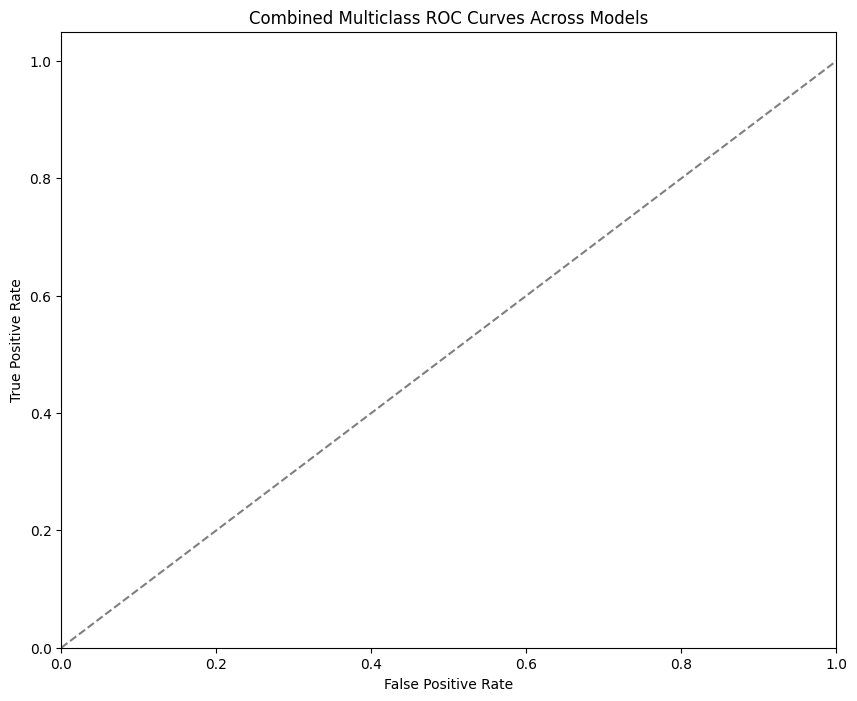


--- Model Comparison Dataframe ---
              Accuracy Precision  Recall F1-Score Avg ROC-AUC
Random Forest   0.9637    0.9758  0.9752    0.975      0.9996
Decision Tree   0.7276    0.8008  0.7019   0.7198      0.8423
KNN              0.937    0.9471  0.9441   0.9439      0.9879
Naive Bayes     0.9654    0.9694  0.9689   0.9691      0.9987
SVM             0.9917    0.9939  0.9938   0.9937         1.0


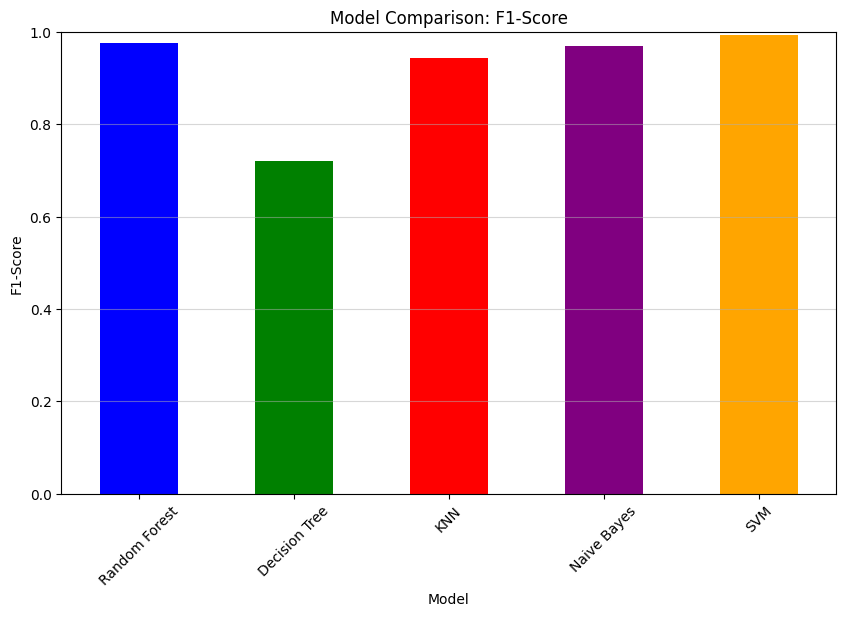

In [48]:
# VISUALIZATION: Finalize combined ROC plot
# Initialize the figure if not already done (in case model cells weren't run)
plt.figure(figsize=(10, 8))  # Ensure figure is set up
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)  # Add diagonal line
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.title('Combined Multiclass ROC Curves Across Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# FIXED: Only show legend if there are labeled artists to avoid UserWarning and blank plot
handles, labels = plt.gca().get_legend_handles_labels()
if labels:
    plt.legend(loc='lower right')
plt.show()

# VISUALIZATION: Bar graph for model comparison
comparison_df = pd.DataFrame(results).T.drop(columns=['Confusion Matrix'])
print("\n--- Model Comparison Dataframe ---")
print(comparison_df)

plt.figure(figsize=(10, 6))
comparison_df['F1-Score'].plot(kind='bar', color=['blue', 'green', 'red', 'purple', 'orange'])  # 5 colors for 5 models
plt.title('Model Comparison: F1-Score')
plt.ylabel('F1-Score')
plt.xlabel('Model')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.5)
plt.show()